# **IMPORTS**

In [1]:
import math
from collections import defaultdict
import matplotlib.pyplot as plt

# **STEP 1: Dataset Definition**

In [2]:
# Each row = [f1, f2, f3, f4, label]
# None = missing value

DATA = [
    [2, 2, 1, 0, 2],
    [2, 0, 1, 1, 0],
    [0, 0, 2, 0, 0],
    [1, 2, 0, 1, 2],
    [0, 2, None, 0, 0],
    [1, 2, 1, 0, 1],
    [1, 1, 1, 2, 0],
    [1, 1, 0, 1, 1],
    [0, 1, 0, 1, 2],
    [0, None, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [2, 2, 2, 0, 2],
    [1, 2, 1, 2, 1],
    [2, 2, 2, 2, 0],
    [0, 1, 2, 2, 2],
    [2, 1, 1, 2, 1],
    [2, 2, 0, 1, 2],
    [1, 1, 2, 1, 1],
    [1, 0, 0, 1, 1],
    [0, 2, 2, 1, 1]
]
FEATURE_NAMES = ["f1", "f2", "f3", "f4"]

# **STEP 2: Data Structures**

In [3]:
class Sample:
    """
    Represents one training sample.
    weight is used for handling missing values (Quinlan method).
    """
    def __init__(self, features, label, weight=1.0):
        self.features = features
        self.label = label
        self.weight = weight

In [4]:
class DecisionNode:
    """
    Internal decision node.
    Splits on a specific feature.
    """
    def __init__(self, feature_index):
        self.feature_index = feature_index
        self.children = {}       # value -> subtree
        self.branch_probs = {}   # value -> probability (for missing)

    def is_leaf(self):
        return False

In [5]:
class LeafNode:
    """
    Leaf node that stores final predicted class.
    """
    def __init__(self, label):
        self.label = label

    def is_leaf(self):
        return True

# **STEP 3: Utility Functions**

In [6]:
def log(depth, message):
    """
    Helper function for printing logs with indentation
    so that recursion levels are easier to read.
    """
    indent = "  " * depth
    print(f"{indent}{message}")

In [7]:
def weighted_majority_class(samples):
    """
    Returns class with highest total weight.
    Used when:
      - No feature left
      - Gain <= 0
    """
    counts = defaultdict(float)
    for s in samples:
        counts[s.label] += s.weight
    return max(counts.items(), key=lambda x: x[1])[0]

In [8]:
def weighted_entropy(samples):
    """
    Computes entropy with sample weights.

    Formula:
        H(S) = - Σ p_i log2(p_i)
    where p_i is weighted probability of class i.
    """
    total_weight = sum(s.weight for s in samples)
    if total_weight == 0:
        return 0.0

    class_weights = defaultdict(float)
    for s in samples:
        class_weights[s.label] += s.weight

    ent = 0.0
    for w in class_weights.values():
        p = w / total_weight
        if p > 0:
            ent -= p * math.log2(p)

    return ent

# **STEP 4: Adjusted Information Gain**


In [9]:
def adjusted_information_gain(samples, feature_index, depth=0):
    """
    Computes Information Gain with Quinlan adjustment.

    Key idea:
    - Only use known values for entropy split
    - Multiply gain by (known_weight / total_weight)
    """

    # Separate known vs missing
    known = [s for s in samples if s.features[feature_index] is not None]
    if len(known) == 0:
        return -1

    total_weight = sum(s.weight for s in samples)
    known_weight = sum(s.weight for s in known)

    parent_entropy = weighted_entropy(known)

    log(depth, f"Evaluating feature {FEATURE_NAMES[feature_index]}")
    log(depth, f"Known weight = {known_weight:.3f} / Total weight = {total_weight:.3f}")
    log(depth, f"Parent entropy = {parent_entropy:.4f}")

    # Group by feature value
    groups = defaultdict(list)
    for s in known:
        groups[s.features[feature_index]].append(s)

    remainder = 0.0

    for value, subset in groups.items():
        subset_weight = sum(x.weight for x in subset)
        subset_entropy = weighted_entropy(subset)

        log(depth, f"  value={value} weight={subset_weight:.3f} entropy={subset_entropy:.4f}")

        remainder += (subset_weight / known_weight) * subset_entropy

    gain = parent_entropy - remainder

    # Adjustment for missing values
    adjustment_factor = known_weight / total_weight
    adjusted_gain = adjustment_factor * gain

    log(depth, f"Information Gain = {gain:.5f}")
    log(depth, f"Adjusted Gain = {adjusted_gain:.5f}")
    log(depth, "-" * 40)

    return adjusted_gain

# **STEP 5: Splitting with Quinlan method**

In [10]:
def split_with_missing(samples, feature_index, depth=0):
    """
    Distributes missing-value samples proportionally
    across branches using branch probabilities.
    """

    known = [s for s in samples if s.features[feature_index] is not None]
    missing = [s for s in samples if s.features[feature_index] is None]

    branches = defaultdict(list)

    # Normal split
    for s in known:
        branches[s.features[feature_index]].append(s)

    known_weight = sum(s.weight for s in known)

    # Compute branch probabilities
    branch_probs = {}
    for value, subset in branches.items():
        branch_weight = sum(x.weight for x in subset)
        branch_probs[value] = branch_weight / known_weight

        log(depth, f"Branch probability P({value}) = {branch_probs[value]:.4f}")

    # Distribute missing samples proportionally
    for sample in missing:
        log(depth, "Distributing missing sample using branch probabilities")

        for value, prob in branch_probs.items():
            copied = Sample(
                features=sample.features,
                label=sample.label,
                weight=sample.weight * prob
            )
            branches[value].append(copied)

    return branches, branch_probs

# **STEP 6: Recursive Tree Building**

In [11]:
def build_tree(samples, available_features, depth=0):
    """
    Recursively builds decision tree using:
    - Entropy
    - Adjusted Information Gain
    """

    log(depth, f"\nBuilding node at depth {depth}")
    log(depth, f"Number of samples = {len(samples)}")

    labels = set(s.label for s in samples)

    # If pure node → make leaf
    if len(labels) == 1:
        label = next(iter(labels))
        log(depth, f"Pure node detected → Leaf({label})")
        return LeafNode(label)

    # If no features left → majority class
    if len(available_features) == 0:
        majority = weighted_majority_class(samples)
        log(depth, f"No features left → Leaf({majority})")
        return LeafNode(majority)

    # Compute gains
    gains = []
    for f in available_features:
        gain = adjusted_information_gain(samples, f, depth + 1)
        gains.append((gain, f))

    gains.sort(reverse=True)
    best_gain, best_feature = gains[0]

    log(depth, f"Best feature = {FEATURE_NAMES[best_feature]} with gain {best_gain:.5f}")

    # Stop if no improvement
    if best_gain <= 0:
        majority = weighted_majority_class(samples)
        log(depth, f"Gain <= 0 → Leaf({majority})")
        return LeafNode(majority)

    node = DecisionNode(best_feature)

    # Split dataset
    branches, probs = split_with_missing(samples, best_feature, depth + 1)
    node.branch_probs = probs

    remaining_features = [f for f in available_features if f != best_feature]

    # Recursive build
    for value, subset in branches.items():
        log(depth, f"Creating branch {FEATURE_NAMES[best_feature]} = {value}")
        node.children[value] = build_tree(
            subset, remaining_features, depth + 1
        )

    return node

# **STEP 7: Tree Visualization**

In [12]:
def count_leaves(node):
    if node.is_leaf():
        return 1
    return sum(count_leaves(c) for c in node.children.values())

In [13]:
def draw_node(ax, node, x, y, width):
    """
    Recursively draws tree using matplotlib.
    """
    if node.is_leaf():
        ax.text(x, y, f"Y={node.label}",
                bbox=dict(boxstyle="round"),
                ha="center")
        return

    feature_name = FEATURE_NAMES[node.feature_index]
    ax.text(x, y, feature_name,
            bbox=dict(boxstyle="square"),
            ha="center")

    total_leaves = count_leaves(node)
    start_x = x - width / 2
    offset = 0

    for value, child in node.children.items():
        child_leaves = count_leaves(child)

        child_x = start_x + width * (offset + child_leaves / 2) / total_leaves
        child_y = y - 1.5

        ax.plot([x, child_x], [y, child_y])
        ax.text((x + child_x) / 2,
                (y + child_y) / 2,
                str(value))

        draw_node(ax, child, child_x, child_y,
                  width * child_leaves / total_leaves)

        offset += child_leaves

In [14]:
def draw_tree(tree, save_path):
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis("off")

    draw_node(ax, tree, x=0.5, y=0.95, width=0.9)

    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

# **STEP 8: Main Execution**

In [15]:
def run_decision_tree_process():
    """
    Wrapper function for running the whole process.
    """

    print("=" * 60)
    print("Decision Tree using Entropy Reduction")
    print("Missing Values handled using Quinlan method")
    print("=" * 60)

    # Convert raw data to Sample objects
    samples = [Sample(row[:-1], row[-1]) for row in DATA]


    tree = build_tree(samples, list(range(len(FEATURE_NAMES))))

    draw_tree(tree, 'output/decision_tree.png' ) 

Decision Tree using Entropy Reduction
Missing Values handled using Quinlan method

Building node at depth 0
Number of samples = 20
  Evaluating feature f1
  Known weight = 20.000 / Total weight = 20.000
  Parent entropy = 1.5813
    value=2 weight=6.000 entropy=1.4591
    value=0 weight=7.000 entropy=1.3788
    value=1 weight=7.000 entropy=1.1488
  Information Gain = 0.25888
  Adjusted Gain = 0.25888
  ----------------------------------------
  Evaluating feature f2
  Known weight = 19.000 / Total weight = 20.000
  Parent entropy = 1.5810
    value=2 weight=9.000 entropy=1.5305
    value=0 weight=4.000 entropy=0.8113
    value=1 weight=6.000 entropy=1.4591
  Information Gain = 0.22448
  Adjusted Gain = 0.21326
  ----------------------------------------
  Evaluating feature f3
  Known weight = 19.000 / Total weight = 20.000
  Parent entropy = 1.5810
    value=1 weight=7.000 entropy=1.4488
    value=2 weight=6.000 entropy=1.5850
    value=0 weight=6.000 entropy=1.4591
  Information Gain 

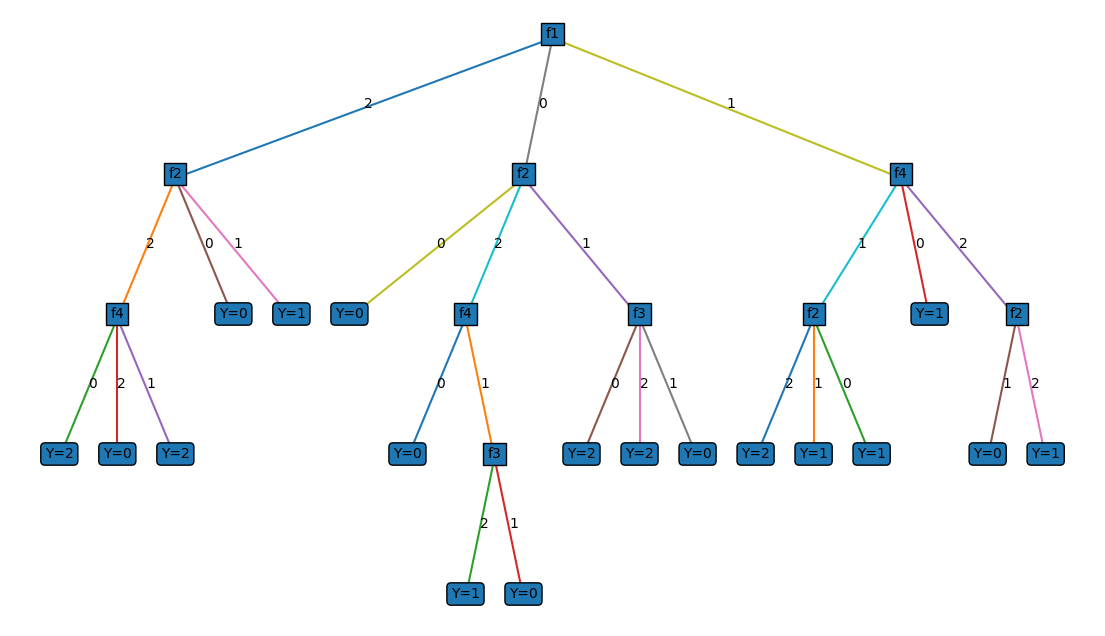

In [16]:
run_decision_tree_process()